# Analyse Titanic 🚢
Exploration et analyse du dataset Titanic avec Pandas.
Questions : qui survivait ? Pourquoi ?

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/titanic.csv")
print("✅ Dataset chargé")
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")

✅ Dataset chargé
Dimensions : 891 lignes x 12 colonnes


In [11]:
# Affiche les 5 premières lignes
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
# Informations générales sur le dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
# Statistiques descriptives
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
# Valeurs manquantes par colonne
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
# Combien ont survécu ?
survie = df['Survived'].value_counts()
print(survie)
print(f"\nTaux de survie : {df['Survived'].mean()*100:.1f}%")

Survived
0    549
1    342
Name: count, dtype: int64

Taux de survie : 38.4%


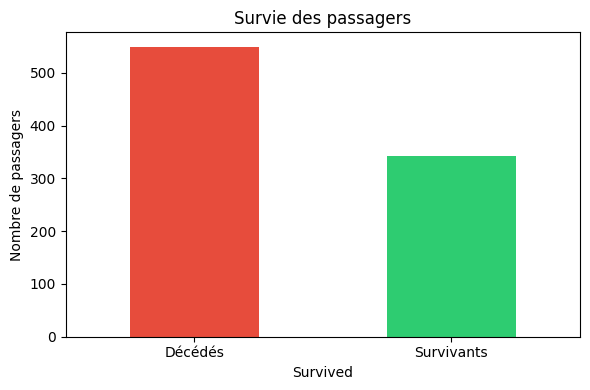

In [16]:
# Graphique survie
df['Survived'].value_counts().plot(
    kind='bar', 
    color=['#E74C3C', '#2ECC71'],
    figsize=(6,4)
)
plt.title("Survie des passagers")
plt.xticks([0,1], ['Décédés', 'Survivants'], rotation=0)
plt.ylabel("Nombre de passagers")
plt.tight_layout()
plt.show()

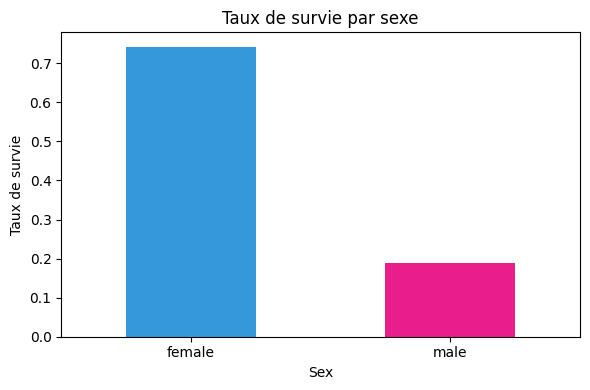

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [17]:
# Les femmes survivaient-elles plus que les hommes ?
df.groupby('Sex')['Survived'].mean().plot(
    kind='bar',
    color=['#3498DB', '#E91E8C'],
    figsize=(6,4)
)
plt.title("Taux de survie par sexe")
plt.xticks(rotation=0)
plt.ylabel("Taux de survie")
plt.tight_layout()
plt.show()

print(df.groupby('Sex')['Survived'].mean()*100)

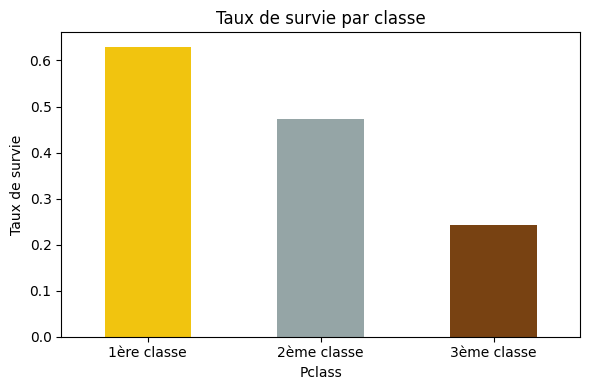

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [18]:
# Les riches survivaient-ils plus ?
df.groupby('Pclass')['Survived'].mean().plot(
    kind='bar',
    color=['#F1C40F','#95A5A6','#784212'],
    figsize=(6,4)
)
plt.title("Taux de survie par classe")
plt.xticks([0,1,2], ['1ère classe','2ème classe','3ème classe'], rotation=0)
plt.ylabel("Taux de survie")
plt.tight_layout()
plt.show()

print(df.groupby('Pclass')['Survived'].mean()*100)

# Cellule Markdown finale
# ## Ce que j'ai appris
# - Charger un CSV avec Pandas
# - Explorer un dataset : shape, info, describe, isnull
# - Calculer des taux de survie avec groupby + mean
# - Visualiser avec Matplotlib
# - Conclusion : le sexe et la classe sociale influençaient fortement la survie

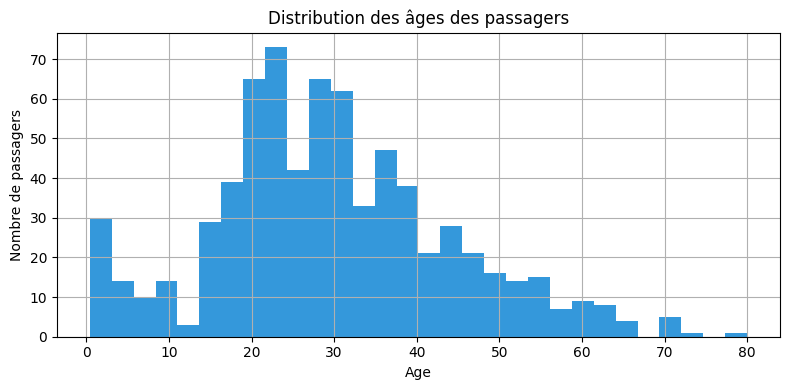

Age moyen : 29.7 ans
Age médian : 28.0 ans
Valeurs manquantes : 177


In [19]:
# Distribution des âges
df['Age'].hist(bins=30, color='#3498DB', figsize=(8,4))
plt.title("Distribution des âges des passagers")
plt.xlabel("Age")
plt.ylabel("Nombre de passagers")
plt.tight_layout()
plt.show()

print(f"Age moyen : {df['Age'].mean():.1f} ans")
print(f"Age médian : {df['Age'].median():.1f} ans")
print(f"Valeurs manquantes : {df['Age'].isnull().sum()}")

C:\Users\Eartrh\AppData\Local\Temp\ipykernel_13108\2994815418.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tranche_age')['Survived'].mean().plot(


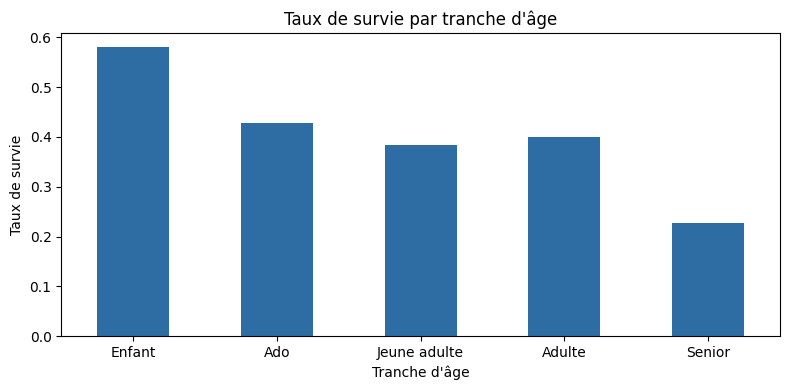

tranche_age
Enfant          57.971014
Ado             42.857143
Jeune adulte    38.268156
Adulte          40.000000
Senior          22.727273
Name: Survived, dtype: float64


C:\Users\Eartrh\AppData\Local\Temp\ipykernel_13108\2994815418.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('tranche_age')['Survived'].mean()*100)


In [20]:
# Créer des tranches d'âge
df['tranche_age'] = pd.cut(df['Age'], 
                            bins=[0, 12, 18, 35, 60, 100],
                            labels=['Enfant', 'Ado', 'Jeune adulte', 'Adulte', 'Senior'])

# Taux de survie par tranche
df.groupby('tranche_age')['Survived'].mean().plot(
    kind='bar',
    color='#2E6DA4',
    figsize=(8,4)
)
plt.title("Taux de survie par tranche d'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Taux de survie")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df.groupby('tranche_age')['Survived'].mean()*100)

Taux de survie (%) par sexe et classe :

Pclass     1     2     3
Sex                     
female  96.8  92.1  50.0
male    36.9  15.7  13.5


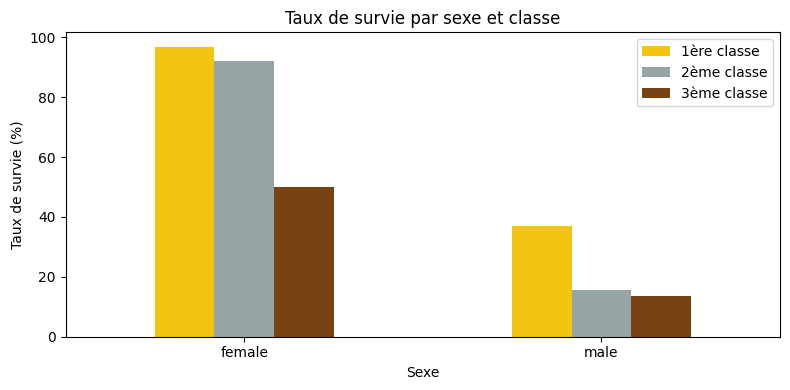

In [21]:
# Tableau croisé : survie par sexe ET classe
pivot = df.pivot_table(
    values='Survived',
    index='Sex',
    columns='Pclass',
    aggfunc='mean'
) * 100

print("Taux de survie (%) par sexe et classe :\n")
print(pivot.round(1))

# Visualisation
pivot.plot(kind='bar', figsize=(8,4), 
           color=['#F1C40F','#95A5A6','#784212'])
plt.title("Taux de survie par sexe et classe")
plt.xlabel("Sexe")
plt.xticks(rotation=0)
plt.ylabel("Taux de survie (%)")
plt.legend(['1ère classe','2ème classe','3ème classe'])
plt.tight_layout()
plt.show()

# Markdown cell
```
```
## Conclusions de l'analyse Titanic 🚢

### Données
- 891 passagers · 38.4% de taux de survie global

### Facteurs qui influençaient la survie

| Facteur | Observation |
|---|---|
| Sexe | Femmes : 74% · Hommes : 19% |
| Classe | 1ère : 63% · 2ème : 47% · 3ème : 24% |
| Age | Enfants prioritaires · seniors désavantagés |
| Combinaison | Homme 3ème classe : ~13% — le pire profil |

### Ce que les données racontent
Le naufrage du Titanic n'était pas qu'une tragédie naturelle —
c'était aussi une tragédie sociale. Le sexe et la classe sociale
déterminaient largement les chances de survie.

### Outils utilisés
`Python` `Pandas` `Matplotlib` `Jupyter`